# Artificial Intelligence
## L.EIC – 3rd Year/2nd Semester
### Exercise Sheet 2
# Informed Search

**a)** Assuming the following search tree in which each arc displays the cost of the corresponding operator, and the nodes contain the value of the heuristic function, identify which node is expanded next using each of the following methods:
- Breadth-first search.
- Depth-first search.
- Uniform cost search.
- Greedy search.
- A* search.

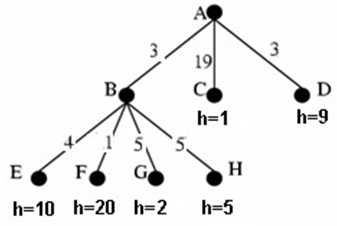

**b)** Assuming the following search tree, identify which node is expanded next using each of the following methods:
- Breadth-first search.
- Depth-first search.
- Uniform cost search.
- Greedy search.
- A* search.

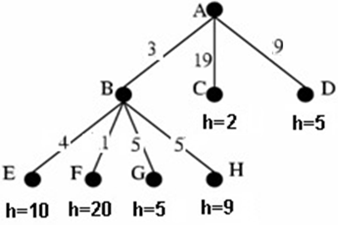

BFS:
A-B-C-D-E-F-G-H
DFS:
A-B-E-F-G-H-C-D
UCS:
A-B-D-F-E-G-H-C
Greedy:
A-C-D-B-G-H-E-F
A*:
A-D-C-B-G-H-E-F

## The Informed Two Buckets Problem

Apply informed search strategies to the two buckets problem. Start by bringing up you definitions for the buckets problem, from the previous notebook.

In [26]:
class BucketState:
    c1 = 4   # capacity for bucket 1
    c2 = 3   # capacity for bucket 2

    def __init__(self, b1, b2):
        self.b1 = b1
        self.b2 = b2

    '''needed for the visited list'''
    def __eq__(self, other):
        if isinstance(other, self.__class__):
            return self.__dict__ == other.__dict__
        else:
            return False

    def __ne__(self, other):
        """Overrides the default implementation (unnecessary in Python 3)"""
        return not self.__eq__(other)

    def __hash__(self):
        return hash((self.b1, self.b2))
    ''' - '''

    def __str__(self):
        return "(" + str(self.b1) + ", " + str(self.b2) + ")"
    
# emptying the first bucket
def empty1(state):
    if state.b1 > 0:
        return BucketState(0, state.b2), state.b1   # using unitary costs
    return None

# emptying the second bucket
def empty2(state):
    if state.b2 > 0:
        return BucketState(state.b1, 0), state.b2   # using unitary costs
    return None




# filling the first bucket
def fill1(state):
    if state.b1 < BucketState.c1:
        return BucketState(BucketState.c1, state.b2), 1
    return None

# filling the second bucket
def fill2(state):
    if state.b2 < BucketState.c2:
        return BucketState(state.b1, BucketState.c2), 1
    return None




# pouring from the first to the second bucket until the target is full
def pour12_fill2(state):
    if state.b1 > 0 and state.b2 < BucketState.c2 and state.b1+state.b2 >= BucketState.c2:
        return BucketState(state.b1 - (BucketState.c2 - state.b2), BucketState.c2), 1
    return None

# pouring from the first to the second bucket until the source is empty
def pour12_empty1(state):
    if state.b1 > 0 and state.b2 < BucketState.c2 and state.b1+state.b2 < BucketState.c2:
        return BucketState(0, state.b1 + state.b2), 1
    return None




# pouring from the second to the first bucket until the target is full
def pour21_fill1(state):
    if state.b2 > 0 and state.b1< BucketState.c1 and state.b2+state.b1 >= BucketState.c1:
        return BucketState(BucketState.c1, state.b2 - (BucketState.c1 - state.b1)), 1
    return None




# pouring from the second to the first bucket until the source is empty
def pour21_empty2(state):
    if state.b2 > 0 and state.b1 < BucketState.c2 and state.b1+state.b2 < BucketState.c1:
        return BucketState(state.b1 + state.b2, 0), 1
    return None


def child_bucket_states(state):
    new_states = []
    if(empty1(state)):
        new_states.append(empty1(state))
    if(empty2(state)):
        new_states.append(empty2(state))
    if(fill1(state)):
        new_states.append(fill1(state))
    if(fill2(state)):
        new_states.append(fill2(state))
    if(pour12_fill2(state)):
        new_states.append(pour12_fill2(state))
    if(pour12_empty1(state)):
        new_states.append(pour12_empty1(state))
    if(pour21_fill1(state)):
        new_states.append(pour21_fill1(state))
    if(pour21_empty2(state)):
        new_states.append(pour21_empty2(state))
    return new_states

def goal_bucket_state(state):
    if (state.b1 == 2):
        return state
    return None

def print_solution(node:TreeNode):
    if node:
        if node.parent:
            print_solution(node.parent)
        print(node.state)
    else:
        print("no solution found")

    return


The first thing you need to do is to define a heuristic function for the problem.

In [8]:
def heuristic_bucket(node):
    # heuristic function for the bucket filling problem
    return abs(node.state.b1 - 2)
    

We also change the TreeNode structure so that we keep the path cost at each node (needed for A*).

In [9]:
# A generic definition of a tree node holding a state of the problem
class TreeNode:
    def __init__(self, state, parent=None):
        self.state = state
        self.parent = parent
        self.children = []
        self.cost = 0   # the path cost to get to this state
    
    def add_child(self, child_node, operator_cost=0):
        self.children.append(child_node)
        child_node.cost = self.cost + operator_cost   # the path cost is the parent's cost plus this operator cost
        child_node.parent = self

##### Greedy search

Implement a generic greedy search algorithm.

In [24]:
def greedy_search(initial_state, goal_state_func, operators_func, heuristic_func):
    root = TreeNode(initial_state)   # create the root node in the search tree
    queue = [(root, heuristic_func(root))]   # initialize the queue to store the nodes
    visited = {initial_state}

    while queue:
        (node, cost) = queue.pop(0)   # get first element in the queue
        print(node.state)
        if goal_state_func(node.state):   # check goal state
            return node

        for state, cost in operators_func(node.state):   # go through next states
            if state not in visited:
                visited.add(state)
                # create tree node with the new state
                child_node = TreeNode(state, node)


                # link child node to its parent in the tree
                node.add_child(child_node, cost)


                # enqueue the child node
                queue.append((child_node, heuristic_func(child_node)))
            
        
        # sort the queue by state heuristic value
        queue.sort(key=lambda x: x[1])
    
    return None

Test it on the two buckets problem.

In [27]:
goal = greedy_search(BucketState(0,0),
                            goal_bucket_state,
                            child_bucket_states,
                            heuristic_bucket)
print_solution(goal)

(0, 0)
(4, 0)
(1, 3)
(1, 0)
(0, 3)
(3, 0)
(3, 3)
(4, 3)
(0, 1)
(4, 2)
(4, 1)
(2, 3)
(0, 0)
(4, 0)
(1, 3)
(1, 0)
(0, 1)
(4, 1)
(2, 3)


##### A*

Implement a generic A* algorithm. This is very similar to greedy search, the difference is that it takes into account the cost of the path so far, together with the heuristic function applied to the current state.

In [32]:
def a_star_search(initial_state, goal_state_func, operators_func, heuristic_func):
    root = TreeNode(initial_state)   # create the root node in the search tree
    queue = [(root, 0 + heuristic_func(root))]   # initialize the queue to store the nodes
    visited = {initial_state}

    while queue:
        (node, cost) = queue.pop(0)   # get first element in the queue
        if goal_state_func(node.state):   # check goal state
            return node

        for state, child_cost in operators_func(node.state):   # go through next states
            if state not in visited:
                visited.add(state)

                # create tree node with the new state
                child_node = TreeNode(state, node)
    
    
                # link child node to its parent in the tree
                node.add_child(child_node)
    
                # enqueue the child node
                queue.append((child_node, child_cost + heuristic_func(child_node)))
            
        
        # sort the queue by state full cost (path cost + heuristic value)
        # your code here
        #--------------------------------------------------#
        queue = sorted(queue, key=lambda x: x[1])
        #--------------------------------------------------#

    return None

Test it on the two buckets problem.

In [33]:
goal = a_star_search(BucketState(0,0),
                            goal_bucket_state,
                            child_bucket_states,
                            heuristic_bucket)
print_solution(goal)

(0, 0)
(4, 0)
(1, 3)
(1, 0)
(0, 1)
(4, 1)
(2, 3)


## The Informed Missionaries and Cannibals Problem

Apply informed search strategies to the missionaries and cannibals problem.

## N-Puzzle Problem

The objective of this exercise is the application of search methods, with emphasis on informed search methods such as A\*, to solve the well-known N-Puzzle problem. The desired objective state for the puzzle is as follows (0 represents the empty space):

<table>
<tr><th>9 Puzzle</th><th></th><th>16 Puzzle</th></tr>
<tr>
<td>

|     |     |     |
| --- | --- | --- |
| 1   | 2   | 3   |
| 4   | 5   | 6   |
| 7   | 8   | 0   |


</td>
<td>
</td>
<td>

|     |     |     |     |
| --- | --- | --- | --- |
| 1   | 2   | 3   | 4   |
| 5   | 6   | 7   | 8   |
| 9   | 10  | 11  | 12  |
| 13  | 14  | 15  | 0   |

</td>
</tr>
</table>

Starting from a given initial state, the goal is to determine which operations to perform to
solve the puzzle, reaching the desired objective state.

**a)** Formulate this problem as a search problem by defining the state representation, initial state, operators (their name, preconditions, effects, and cost), and objective test.

**b)** What is the state space size for this problem?

**c)** Solve the problem by hand, using a search tree, starting with the following state:

<table>
<tr><th>9 Puzzle</th></tr>
<tr>
<td>

|     |     |     |
| --- | --- | --- |
| 1   | 2   | 3   |
| 4   | 6   | 0   |
| 7   | 5   | 8   |

</td>
</tr>
</table>

*(Use paper and pencil.)*

**c)** Here's a possible specification of the problem:

In [ ]:
from copy import deepcopy

# definition of the problem
class NPuzzleState:

    def __init__(self, board, move_history=[]):
        # board(list[list[int]]) - the state of the board
        # move_history(list[list[list[int]]]) - the history of the moves up until this state
        self.board = deepcopy(board)
        (self.blank_row, self.blank_col) = self.find_blank()

        # create an empty array and append move_history
        self.move_history = [] + move_history + [self.board]

    def children(self):
        # returns the possible moves
        functions = [self.up, self.down, self.left, self.right]

        children = []
        for func in functions:
            child = func()
            if child:
                children.append(child)

        return children

    def find_blank(self):
        # finds the blank row and col
        for row in range(len(self.board)):
            for col in range(len(self.board[0])):
                if self.board[row][col] == 0:
                    return (row, col)

    def move(func):
        # decorator function to add to history everytime a move is made
        # functions with @move will apply this decorator
        def wrapper(self):
            state = NPuzzleState(self.board, self.move_history)
            value = func(state)
            if value:
                return state
            else:
                return None

        return wrapper

    @move
    def up(self):
        # moves the blank upwards
        if self.blank_row == 0:
            return False
        else:
            self.board[self.blank_row][self.blank_col] = self.board[self.blank_row - 1][self.blank_col]
            self.board[self.blank_row - 1][self.blank_col] = 0
            self.blank_row -= 1
            return True

    @move
    def down(self):
        # moves the blank downwards
        if self.blank_row == len(self.board) - 1:
            return False
        else:
            self.board[self.blank_row][self.blank_col] = self.board[self.blank_row + 1][self.blank_col]
            self.board[self.blank_row + 1][self.blank_col] = 0
            self.blank_row += 1
            return True

    @move
    def left(self):
        # moves the blank left
        if self.blank_col == 0:
            return False
        else:
            self.board[self.blank_row][self.blank_col] = self.board[self.blank_row][self.blank_col - 1]
            self.board[self.blank_row][self.blank_col - 1] = 0
            self.blank_col -= 1
            return True

    @move
    def right(self):
        # moves the blank right
        if self.blank_col == len(self.board[0]) - 1:
            return False
        else:
            self.board[self.blank_row][self.blank_col] = self.board[self.blank_row][self.blank_col + 1]
            self.board[self.blank_row][self.blank_col + 1] = 0
            self.blank_col += 1
            return True

    def is_complete(self):
        # checks if the board is complete
        for row in range(len(self.board)):
            for col in range(len(self.board[0])):
                if self.board[row][col] != row * len(self.board[0]) + col + 1 and self.board[row][col] != 0:
                    return False
        return True

    def __hash__(self):
        # to be able to use the state in a set
        return hash(str([item for sublist in self.board for item in sublist]))

    def __eq__(self, other):
        # compares the two matrices
        return [item for sublist in self.board for item in sublist] == [item for sublist in other.board for item in sublist]

def print_sequence(sequence):
    print("Steps:", len(sequence) - 1)
    # prints the sequence of states
    for state in sequence:
        for row in state:
            print(row)
        print()


def problems():
    return (
        NPuzzleState([[1, 2, 3], [5, 0, 6], [4, 7, 8]]),
        NPuzzleState([[1, 3, 6], [5, 2, 0], [4, 7, 8]]),
        NPuzzleState([[1, 6, 2], [5, 7, 3], [0, 4, 8]]),
        NPuzzleState([[5, 1, 3, 4], [2, 0, 7, 8], [10, 6, 11, 12], [9, 13, 14, 15]]),
    )

Start by applying breadth-first to this problem.

In [ ]:
def bfs(problem):
    # problem(NPuzzleState) - the initial state
    queue = [problem]
    visited = set()   # to not visit the same state twice

    while queue:
        # your code here
        
        
        
        
        
    
    return None

# prints the sequence for the first problem using bfs
print_sequence(bfs(problems()[2]))

##### Heuristic functions

For greedy search and A*, consider the following heuristics:
- H1 - Number of pieces at the incorrect location.
- H2 - Sum of Manhattan distances of the pieces to their correct locations.

In [ ]:
def target_position(number, side):
    # calculates the target position of a piece given its number
    # number (int) - the number of the piece
    # side (int) - the size of the side of the board (only for square boards)
    if number == 0:
        # if it is the last piece, it is 0
        row = col = side - 1
    else:
        # otherwise it is sequential, starting at 1
        row = (number-1) // side
        col = (number-1) % side
    return (row, col)

def h1(state):
    # heuristic function 1
    # returns the number of incorrect placed pieces in the matrix
    board = state.board
    side = len(board) # the size of the side of the board (only for square boards)

    total = 0
    
    # your code here
    
    
    
    
    
    
    
    
    return total

def h2(state):
    # heuristic function 2
    # returns the sum of manhattan distances from incorrect placed pieces to their correct places
    board = state.board
    side = len(board) # the size of the side of the board (only for square boards)

    total = 0

    # your code here
    
    
    
    
    
    
    
    
    return total

Test your heuristic functions.

##### Greedy search

We now turn to implementing greedy search.

In [ ]:
import heapq # we'll be using a heap to store the states

def greedy_search(problem, heuristic):
    # problem (NPuzzleState) - the initial state
    # heuristic (function) - the heuristic function that takes a board (matrix), and returns an integer
    setattr(NPuzzleState, "__lt__", lambda self, other: heuristic(self) < heuristic(other))
    states = [problem]
    visited = set()   # to not visit the same state twice
    
    while states:
        # your code here
        # heapq.heappop(states) can be used to POP a state from the state list
        # heapq.heappush(states, new_state) can be used to APPEND a new state to the state list
        
        
        
        
        
        
        
        
        
    
    return None

In [ ]:
print('h1')
print_sequence(greedy_search(problems()[3], h1))

print('h2')
print_sequence(greedy_search(problems()[3], h2))

##### A*

And now A*.

In [ ]:
import heapq # we'll be using a heap to store the states

def a_star_search(problem, heuristic):
    # problem (NPuzzleState) - the initial state
    # heuristic (function) - the heuristic function that takes a board (matrix), and returns an integer
    setattr(NPuzzleState, "__lt__", lambda self, other: heuristic(self) + len(self.move_history) < heuristic(other) + len(other.move_history))
    states = [problem]
    visited = set()   # to not visit the same state twice
    # Note: in the case of A*, a second finding of the same state might actually be a better path; this implementation does not take that into account
    
    while states:
        # your code here
        # heapq.heappop(states) can be used to POP a state from the state list
        # heapq.heappush(states, new_state) can be used to APPEND a new state to the state list
        
        
        
        
        
        
        
        
        
        
        
    
    return None

In [ ]:
print('h1')
print_sequence(a_star_search(problems()[3], h1))

print('h2')
print_sequence(a_star_search(problems()[3], h2))

Compare the results obtained concerning execution time and memory space in solving the following problems:

<table>
<tr><th>Prob. 1</th><th>Prob. 2</th><th>Prob. 3</th><th>Prob. 4</th></tr>
<tr>
<td>

|     |     |     |
| --- | --- | --- |
| 1   | 2   | 3   |
| 5   | 0   | 6   |
| 4   | 7   | 8   |

</td>
<td>

|     |     |     |
| --- | --- | --- |
| 1   | 3   | 6   |
| 5   | 2   | 0   |
| 4   | 7   | 8   |

</td>
<td>

|     |     |     |
| --- | --- | --- |
| 1   | 6   | 2   |
| 5   | 7   | 3   |
| 0   | 4   | 8   |

</td>
<td>

|     |     |     |     |
| --- | --- | --- | --- |
| 5   | 1   | 3   | 4   |
| 2   | 0   | 7   | 8   |
| 10  | 6   | 11  | 12  |
| 9   | 13  | 14  | 15  |

</td>
</tr>
</table>

In [ ]:
import time

# your code here
# (note that the four problems are already defined in "problems()")









